<a href="https://colab.research.google.com/github/prajjaldhar/DataScience/blob/main/Graduate_Admission_Prediction_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Graduate Admission Prediction using ANN

**Dataset:** Kaggle — Graduate Admissions by Mohan S. Acharya  
**Problem:** Predict whether an applicant is likely to be admitted using an Artificial Neural Network (ANN).

> **Important:** The original Kaggle target, `Chance of Admit`, is a continuous probability-like value.  
> For an **accuracy score**, this notebook creates a classification target:
>
> - `1` → Chance of Admit ≥ **0.75**
> - `0` → Chance of Admit < **0.75**
>
> The notebook also reports **regression metrics** (MAE, RMSE, R²) against the original `Chance of Admit` so that we do not lose information from the original dataset.

### Features
- GRE Score
- TOEFL Score
- University Rating
- SOP
- LOR
- CGPA
- Research

**Goal:** Build the complete pipeline — data loading → EDA → preprocessing → train/test split → scaling → ANN → evaluation → accuracy/confusion matrix → sample prediction.

## 1. Why ANN for this problem?

An ANN learns a non-linear relationship between the applicant's academic/profile features and the admission outcome.

Conceptually:

**Input features → Hidden layers → Output**

The hidden layers learn combinations such as:

`GRE + TOEFL + CGPA + Research → learned representation → admission probability`

Because the input variables have different numerical ranges, we will use **StandardScaler** before sending the data into the ANN.

In [ ]:
# Install packages if required
# Uncomment the following line in a fresh environment:
# !pip install -q kagglehub tensorflow scikit-learn pandas matplotlib seaborn

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Load the Kaggle dataset

This notebook uses the official Kaggle dataset:

`mohansacharya/graduate-admissions`

In [ ]:
# Load Kaggle dataset

df = pd.read_csv('/content/Admission_Predict.csv')

df.columns = df.columns.str.strip()

print("Shape:", df.shape)
display(df.head())

Shape: (400, 9)


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


## 3. Understand the data

Before training a neural network, we inspect:
- shape
- data types
- missing values
- duplicate rows
- summary statistics

This prevents us from blindly feeding dirty data into the model.

In [ ]:
print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nSummary statistics:")
display(df.describe())

Shape: (400, 9)

Data types:


,0
Serial No.,int64
GRE Score,int64
TOEFL Score,int64
University Rating,int64
SOP,float64
LOR,float64
CGPA,float64
Research,int64
Chance of Admit,float64



Missing values:


,missing_values
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0



Duplicate rows: 0

Summary statistics:


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,200.500000,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.724350
std,115.614301,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.142609
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.340000
25%,100.750000,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.640000
50%,200.500000,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.730000
75%,300.250000,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,0.830000
max,400.000000,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,0.970000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18516 entries, 0 to 18515
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ref           18516 non-null  object 
 1   title         18516 non-null  object 
 2   subtitle      8010 non-null   object 
 3   creator       18512 non-null  object 
 4   description   18516 non-null  object 
 5   version       18516 non-null  int64  
 6   keywords      5675 non-null   object 
 7   last_updated  18516 non-null  object 
 8   license_name  18516 non-null  object 
 9   size          18516 non-null  object 
 10  size(bytes)   18516 non-null  float64
 11  downloads     18516 non-null  int64  
 12  discussions   18516 non-null  int64  
 13  views         18516 non-null  int64  
 14  likes         18516 non-null  int64  
 15  kernels       18516 non-null  int64  
dtypes: float64(1), int64(6), object(9)
memory usage: 2.3+ MB


## 4. Exploratory Data Analysis

`Chance of Admit` is strongly related to variables such as CGPA, GRE and TOEFL. We will inspect the correlation matrix to understand the relationships before modelling.

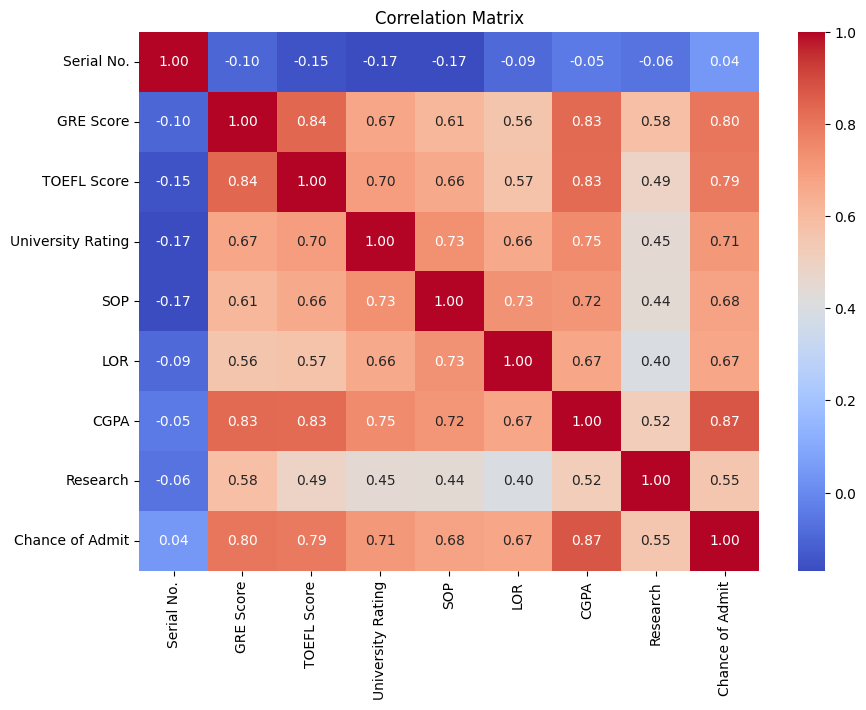

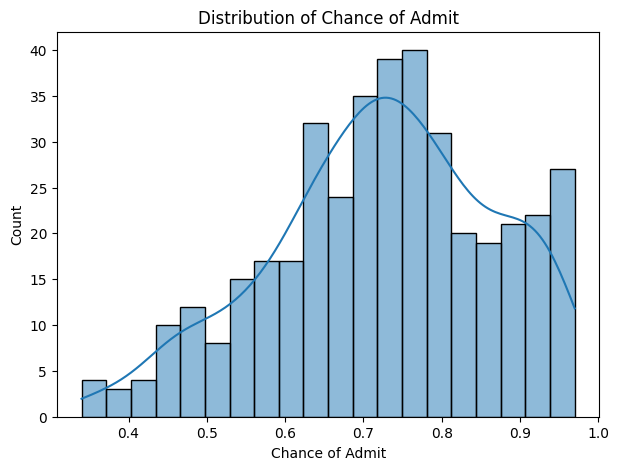

In [ ]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

plt.figure(figsize=(7, 5))
sns.histplot(df["Chance of Admit"], bins=20, kde=True)
plt.title("Distribution of Chance of Admit")
plt.xlabel("Chance of Admit")
plt.show()

## 5. Create the classification target

The original target is continuous. Therefore, `accuracy_score` is not directly appropriate unless we define a classification problem.

We use **0.75** as the threshold:

- `Chance of Admit >= 0.75` → **Admitted / High Chance (1)**
- `Chance of Admit < 0.75` → **Not Admitted / Lower Chance (0)**

We keep the original continuous target as `y_regression` for additional evaluation.

In [ ]:
TARGET = "Chance of Admit"

# Keep the original continuous target
y_regression = df[TARGET].astype(float)

# Create binary classification target for accuracy
ADMISSION_THRESHOLD = 0.75
y_class = (y_regression >= ADMISSION_THRESHOLD).astype(int)

print(y_class.value_counts())

# Input features: Serial No. is an identifier, not a predictive feature
feature_columns = [
    "GRE Score",
    "TOEFL Score",
    "University Rating",
    "SOP",
    "LOR",
    "CGPA",
    "Research"
]

X = df[feature_columns].copy()

print("\nFeatures:", feature_columns)
print("\nClass distribution:")
display(y_class.value_counts().rename(index={0: "Not admitted", 1: "Admitted"}))

print("\nClass proportions:")
display(y_class.value_counts(normalize=True).rename(index={0: "Not admitted", 1: "Admitted"}))

Chance of Admit
0    220
1    180
Name: count, dtype: int64

Features: ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research']

Class distribution:


,count
Chance of Admit,
Not admitted,220
Admitted,180



Class proportions:


,proportion
Chance of Admit,
Not admitted,0.55
Admitted,0.45


## 6. Train-test split

We keep **20%** of the data completely unseen during training.

`stratify=y_class` preserves approximately the same admitted/not-admitted ratio in both sets.

This is important because evaluating on training data would give an overly optimistic score.

In [ ]:
X_train, X_test, y_train, y_test, y_train_reg, y_test_reg = train_test_split(
    X,
    y_class,
    y_regression,
    test_size=0.20,
    random_state=SEED,
    stratify=y_class
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (320, 7)
X_test : (80, 7)
y_train: (320,)
y_test : (80,)


## 7. Feature scaling

ANNs train using gradient descent. If one feature is around 330 (GRE) while another is around 9 (CGPA), their raw scales are very different.

`StandardScaler` transforms each feature approximately to:

**z = (x − mean) / standard deviation**

We fit the scaler **only on the training data** to avoid data leakage.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("First scaled row:")
print(X_train_scaled[0])

Scaled training data shape: (320, 7)
First scaled row:
[0.72079071 0.0874249  0.75075931 1.09859828 0.62881906 0.7749335
 0.89883792]


## 8. Build the ANN

Architecture:

**7 input features → Dense(32, ReLU) → Dropout → Dense(16, ReLU) → Dropout → Dense(1, Sigmoid)**

Why?

- `Dense`: fully connected neural-network layer
- `ReLU`: learns non-linear relationships
- `Dropout`: reduces overfitting
- `Sigmoid`: outputs a value between 0 and 1, which we interpret as the probability of class 1

Because this is binary classification, we use **binary cross-entropy** as the loss function.

In [ ]:
def build_ann(input_dim):
    model = Sequential([
        Dense(32, activation="relu", input_shape=(input_dim,)),
        Dropout(0.20),
        Dense(16, activation="relu"),
        Dropout(0.10),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

model = build_ann(X_train_scaled.shape[1])
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801 (3.13 KB)

 Trainable params: 801 (3.13 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Train the ANN

`EarlyStopping` monitors validation loss. If the model stops improving, training is stopped and the best weights are restored.

This helps reduce overfitting on this relatively small dataset.

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=300,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8633 - loss: 0.2847 - val_accuracy: 0.8906 - val_loss: 0.2536
Epoch 2/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8672 - loss: 0.2802 - val_accuracy: 0.8906 - val_loss: 0.2559
Epoch 3/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8711 - loss: 0.2821 - val_accuracy: 0.8750 - val_loss: 0.2584
Epoch 4/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8828 - loss: 0.2624 - val_accuracy: 0.8750 - val_loss: 0.2593
Epoch 5/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8828 - loss: 0.2671 - val_accuracy: 0.8750 - val_loss: 0.2582
Epoch 6/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8789 - loss: 0.2785 - val_accuracy: 0.8750 - val_loss: 0.2585
Epoch 7/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8711 - loss: 0.2602 - val_accuracy: 0.8750 - val_loss: 0.2596
Epoch 8/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8828 - loss: 0.2619 - val_accuracy: 0.8750

## 10. Training curves

These curves help us see whether the ANN is learning or overfitting.

Ideally:
- training loss decreases
- validation loss decreases
- training and validation accuracy remain reasonably close

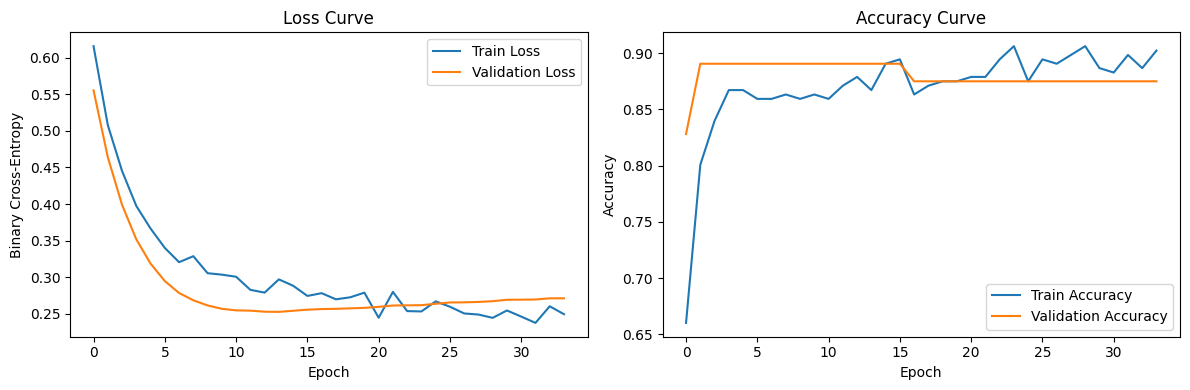

In [ ]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_df["loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["accuracy"], label="Train Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## 11. Predict on unseen test data

The ANN outputs probabilities.

For classification, we convert probability to class:

**probability ≥ 0.50 → class 1**

The 0.50 threshold is a model-decision threshold and is different from the **0.75 target-definition threshold** used earlier.

In [ ]:
y_prob = model.predict(X_test_scaled, verbose=0).ravel()
y_pred = (y_prob >= 0.50).astype(int)

accuracy = accuracy_score(y_test, y_pred)

print(f"ANN Accuracy: {accuracy:.4f}")
print(f"ANN Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Admitted", "Admitted"]
))

ANN Accuracy: 0.8750
ANN Accuracy: 87.50%

Classification Report:
              precision    recall  f1-score   support

Not Admitted       0.87      0.91      0.89        44
    Admitted       0.88      0.83      0.86        36

    accuracy                           0.88        80
   macro avg       0.88      0.87      0.87        80
weighted avg       0.88      0.88      0.87        80



## 12. Confusion matrix

A confusion matrix shows:
- **True Negative:** correctly predicted lower chance
- **True Positive:** correctly predicted high chance
- **False Positive:** predicted high chance but actual class is lower
- **False Negative:** predicted lower chance but actual class is high

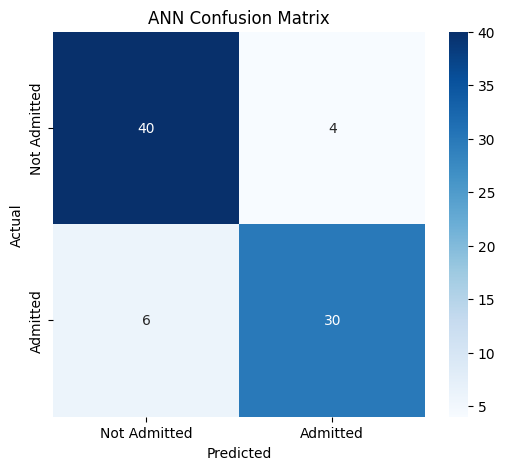

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Admitted", "Admitted"],
    yticklabels=["Not Admitted", "Admitted"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ANN Confusion Matrix")
plt.show()

## 13. Regression metrics on the original `Chance of Admit`

Although the main project reports **classification accuracy**, the original Kaggle target is continuous.

We therefore also evaluate the model's probability output against the original continuous target using:

- **MAE** — average absolute error
- **RMSE** — penalizes larger errors more strongly
- **R²** — proportion of variance explained

This gives a more complete picture than accuracy alone.

In [ ]:
# Convert class probability into a simple admission-chance estimate.
# This is a classification ANN, so this is not a dedicated regression ANN.
# It is included only as an additional diagnostic.

mae = mean_absolute_error(y_test_reg, y_prob)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_prob))
r2 = r2_score(y_test_reg, y_prob)

print(f"MAE :  {mae:.4f}")
print(f"RMSE:  {rmse:.4f}")
print(f"R²  :  {r2:.4f}")

MAE :  0.3310
RMSE:  0.4073
R²  :  -6.1782


## 14. Make a prediction for a new student

Enter the student's profile below.

The model returns:
1. ANN probability of the **high-admission-chance class**
2. predicted class

Example values are within the ranges represented in the Kaggle dataset.

In [ ]:
def predict_admission(
    gre_score,
    toefl_score,
    university_rating,
    sop,
    lor,
    cgpa,
    research
):
    student = pd.DataFrame([{
        "GRE Score": gre_score,
        "TOEFL Score": toefl_score,
        "University Rating": university_rating,
        "SOP": sop,
        "LOR": lor,
        "CGPA": cgpa,
        "Research": research
    }])

    student_scaled = scaler.transform(student)
    probability = float(model.predict(student_scaled, verbose=0)[0][0])
    prediction = int(probability >= 0.50)

    return {
        "ANN probability": probability,
        "Predicted class": prediction,
        "Interpretation": (
            "High admission chance class"
            if prediction == 1
            else "Lower admission chance class"
        )
    }

# Example applicant
result = predict_admission(
    gre_score=325,
    toefl_score=110,
    university_rating=4,
    sop=4.0,
    lor=4.0,
    cgpa=9.0,
    research=1
)

result

{'ANN probability': 0.8861616849899292,
 'Predicted class': 1,
 'Interpretation': 'High admission chance class'}

## 15. Final conclusion

### What we did

1. Loaded the **Kaggle Graduate Admissions** dataset.
2. Inspected shape, data types, missing values and duplicates.
3. Performed basic EDA and correlation analysis.
4. Removed `Serial No.` because it is only an identifier.
5. Converted continuous `Chance of Admit` into a binary target using **0.75**.
6. Split the data into training and testing sets.
7. Standardized features using `StandardScaler`.
8. Built an ANN with ReLU hidden layers and a Sigmoid output.
9. Used Adam + Binary Cross-Entropy for optimization.
10. Used Early Stopping to reduce overfitting.
11. Evaluated the unseen test set using **Accuracy, Precision, Recall, F1-score and Confusion Matrix**.
12. Also reported **MAE, RMSE and R²** as additional diagnostics.

### Key result

Run the evaluation cell to get the exact **ANN Accuracy Score** for this train/test split. Because neural-network training is stochastic and the dataset is small, the exact score can vary slightly across environments.

### Important modelling note

`Chance of Admit` is fundamentally a continuous target. If the objective is to predict the **actual admission probability**, a dedicated ANN regression model is statistically more appropriate. This notebook uses classification because you specifically requested an **accuracy score**.

### Dataset reference

Kaggle dataset: **Graduate Admissions — Mohan S. Acharya**

Source: https://www.kaggle.com/datasets/mohansacharya/graduate-admissions

The dataset is described as a graduate-admission prediction dataset containing GRE, TOEFL, university rating, SOP, LOR, CGPA, research experience and Chance of Admit.